In [1]:
# IMPORT LIBRARIES

import sys, os, glob, gc, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb

from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, label_binarize
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    log_loss, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc as sk_auc
)
import joblib

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120

print("="*80)
print("RETRAINING WITH CLASS WEIGHTS (BALANCED)")
print("="*80)

RETRAINING WITH CLASS WEIGHTS (BALANCED)


In [2]:
# CONFIG

CSV_FOLDER   = './MachineLearningCVE'  
LABEL_COL    = 'Label'
N_FOLDS      = 10
TEST_SIZE    = 0.30        
RANDOM_STATE = 42
OUTPUT_DIR   = '.'
os.makedirs(OUTPUT_DIR, exist_ok=True)

import sklearn
print(f'Scikit-learn : {sklearn.__version__}')
print(f'LightGBM     : {lgb.__version__}')
print(f'Pandas       : {pd.__version__}')

Scikit-learn : 1.8.0
LightGBM     : 4.6.0
Pandas       : 3.0.3


In [3]:
# LOAD DATA

csv_files = sorted(glob.glob(os.path.join(CSV_FOLDER, '*.csv')))
if not csv_files:
    raise FileNotFoundError(f'No CSV files in {CSV_FOLDER}')
dfs = []
for f in csv_files:
    print(f'  Loading {os.path.basename(f)}')
    dfs.append(pd.read_csv(f, low_memory=False, encoding='latin-1'))
df = pd.concat(dfs, ignore_index=True)
print(f'Total rows: {len(df):,}')
del dfs; gc.collect()

  Loading Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
  Loading Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
  Loading Friday-WorkingHours-Morning.pcap_ISCX.csv
  Loading Monday-WorkingHours.pcap_ISCX.csv
  Loading Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  Loading Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
  Loading Tuesday-WorkingHours.pcap_ISCX.csv
  Loading Wednesday-workingHours.pcap_ISCX.csv
Total rows: 2,830,743


20

In [4]:
# CLEAN DATA

df.columns = df.columns.str.strip()

# Drop irrelevant ID columns
drop_cols = [c for c in ['Flow ID','Source IP','Destination IP','Timestamp',
                          'Src IP','Dst IP','src_ip','dst_ip'] if c in df.columns]
if drop_cols:
    df.drop(columns=drop_cols, inplace=True)

# Replace infinities with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop COLUMNS with >50% missing
df.dropna(axis=1, thresh=int(len(df) * 0.5), inplace=True)  
df.dropna(axis=0, inplace=True)                               

# Deduplicate BEFORE the train/test split
before = len(df)
df.drop_duplicates(inplace=True)
print(f'Dedup removed {before - len(df):,} rows')
print(f'Shape after dedup: {df.shape}')

Dedup removed 307,078 rows
Shape after dedup: (2520798, 79)


In [5]:
# CLASS DISTRIBUTION ANALYSIS

class_counts    = df[LABEL_COL].value_counts()
class_names_raw = class_counts.index.tolist()
n_classes_raw   = len(class_names_raw)

print("\n" + "="*80)
print("CLASS DISTRIBUTION (IMBALANCED)")
print("="*80)
print(class_counts)
print(f"\nTotal: {len(df):,} samples")

print("\nPercentages:")
for cls, count in class_counts.items():
    pct = (count / len(df)) * 100
    print(f"  {cls}: {count:,} ({pct:.2f}%)")


CLASS DISTRIBUTION (IMBALANCED)
Label
BENIGN                          2095057
DoS Hulk                         172846
DDoS                             128014
PortScan                          90694
DoS GoldenEye                     10286
FTP-Patator                        5931
DoS slowloris                      5385
DoS Slowhttptest                   5228
SSH-Patator                        3219
Bot                                1948
Web Attack ï¿½ Brute Force         1470
Web Attack ï¿½ XSS                  652
Infiltration                         36
Web Attack ï¿½ Sql Injection         21
Heartbleed                           11
Name: count, dtype: int64

Total: 2,520,798 samples

Percentages:
  BENIGN: 2,095,057 (83.11%)
  DoS Hulk: 172,846 (6.86%)
  DDoS: 128,014 (5.08%)
  PortScan: 90,694 (3.60%)
  DoS GoldenEye: 10,286 (0.41%)
  FTP-Patator: 5,931 (0.24%)
  DoS slowloris: 5,385 (0.21%)
  DoS Slowhttptest: 5,228 (0.21%)
  SSH-Patator: 3,219 (0.13%)
  Bot: 1,948 (0.08%)
  Web Attac

In [6]:
# ENCODE & SCALE

le = LabelEncoder()
df['label_enc'] = le.fit_transform(df[LABEL_COL].astype(str))
class_names = le.classes_
n_classes   = len(class_names)
print(f'\nClasses ({n_classes}):')
for i, n in enumerate(class_names): 
    print(f'  {i:2d}: {n}')

X = df.drop(columns=[LABEL_COL, 'label_enc']).select_dtypes(include=[np.number])
y = df['label_enc']

# 70/30 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print(f'\nTrain: {X_train.shape} | Test: {X_test.shape}')

scaler  = MinMaxScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test  = pd.DataFrame(scaler.transform(X_test),      columns=X.columns)

del df; gc.collect()
print('Encoding & scaling done ✔')


Classes (15):
   0: BENIGN
   1: Bot
   2: DDoS
   3: DoS GoldenEye
   4: DoS Hulk
   5: DoS Slowhttptest
   6: DoS slowloris
   7: FTP-Patator
   8: Heartbleed
   9: Infiltration
  10: PortScan
  11: SSH-Patator
  12: Web Attack ï¿½ Brute Force
  13: Web Attack ï¿½ Sql Injection
  14: Web Attack ï¿½ XSS

Train: (1764558, 78) | Test: (756240, 78)
Encoding & scaling done ✔


In [7]:
# MODEL PARAMETERS WITH CLASS WEIGHTS
print("\n" + "="*80)
print("MODEL CONFIGURATION (WITH CLASS WEIGHTS)")
print("="*80)

# LightGBM base learner with class weights
lgbm_params = dict(
    objective         = 'multiclass',
    metric            = 'multi_logloss',
    num_class         = n_classes,
    n_estimators      = 100,          
    learning_rate     = 0.05,
    max_depth         = 8,
    num_leaves        = 63,
    min_child_samples = 20,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.1,
    reg_lambda        = 0.1,
    is_unbalance      = True,        
    class_weight      = 'balanced',  # NEW: Balance minority classes
    device            = 'cpu',
    random_state      = RANDOM_STATE,
    n_jobs            = -1,
    verbose           = -1,
)

# Bagging + DT with class weights
n_features = X_train.shape[1]
bagging_params = dict(
    estimator   = DecisionTreeClassifier(
                      criterion     = 'gini',
                      max_depth     = 10,
                      min_samples_split = 20,
                      min_samples_leaf  = 10,
                      class_weight  = 'balanced',  # Keeps balanced
                      random_state  = RANDOM_STATE
                  ),
    n_estimators = 50,
    max_samples  = 0.8,
    max_features = max(1, int(np.sqrt(n_features))), 
    bootstrap    = True,
    n_jobs       = -1,
    random_state = RANDOM_STATE,
)

print(f'✓ LightGBM: is_unbalance=True + class_weight="balanced"')
print(f'✓ Bagging: DecisionTree with class_weight="balanced"')
print(f'✓ Meta-learner: LogisticRegression with class_weight="balanced"')
print(f'LightGBM max_features: {bagging_params["max_features"]} (sqrt of {n_features})')
print('Model definitions OK ✔')


MODEL CONFIGURATION (WITH CLASS WEIGHTS)
✓ LightGBM: is_unbalance=True + class_weight="balanced"
✓ Bagging: DecisionTree with class_weight="balanced"
✓ Meta-learner: LogisticRegression with class_weight="balanced"
LightGBM max_features: 8 (sqrt of 78)
Model definitions OK ✔


In [8]:
# CROSS-VALIDATION WITH STACKING
print(f'\nRunning {N_FOLDS}-Fold CV...\n')
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

Xa  = X_train.values
ya  = y_train.values
Xta = X_test.values

oof_lgbm    = np.zeros((len(Xa), n_classes))
oof_bagging = np.zeros((len(Xa), n_classes))
test_lgbm_accum    = np.zeros((len(Xta), n_classes))
test_bagging_accum = np.zeros((len(Xta), n_classes))

fold_results   = []   
fold_loss_curves = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(Xa, ya), 1):
    print(f'  Fold {fold}/{N_FOLDS}', end='')
    Xtr, Xval = Xa[tr_idx], Xa[val_idx]
    ytr, yval = ya[tr_idx], ya[val_idx]

    # LightGBM 
    lgbm_fold = lgb.LGBMClassifier(**lgbm_params)
    evals = {}
    lgbm_fold.fit(
        Xtr, ytr,
        eval_set       = [(Xtr, ytr), (Xval, yval)],
        eval_names     = ['train', 'eval'],
        callbacks      = [
            lgb.record_evaluation(evals),
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(-1),
        ],
    )
    oof_lgbm[val_idx]   = lgbm_fold.predict_proba(Xval)
    test_lgbm_accum    += lgbm_fold.predict_proba(Xta) 

    train_loss = evals['train']['multi_logloss']
    val_loss   = evals['eval']['multi_logloss']
    best_iter  = lgbm_fold.best_iteration_
    fold_loss_curves.append({
        'fold': fold, 'train': train_loss, 'eval': val_loss, 'best': best_iter
    })
    print(f' | LGBM OK (best={best_iter})', end='')

    # Bagging + DT 
    bagging_fold = BaggingClassifier(**bagging_params)
    bagging_fold.fit(Xtr, ytr)
    oof_bagging[val_idx]   = bagging_fold.predict_proba(Xval)
    test_bagging_accum    += bagging_fold.predict_proba(Xta)
    print(' | Bagging OK')

    oof_val_pred_lgbm    = np.argmax(oof_lgbm[val_idx], axis=1)
    oof_val_pred_bagging = np.argmax(oof_bagging[val_idx], axis=1)

    fold_results.append({
        'fold'           : fold,
        'val_loss_lgbm'  : val_loss[best_iter - 1] if best_iter else val_loss[-1],
        'lgbm_acc'       : accuracy_score(yval, oof_val_pred_lgbm),
        'lgbm_f1'        : f1_score(yval, oof_val_pred_lgbm, average='weighted', zero_division=0),
        'bagging_acc'    : accuracy_score(yval, oof_val_pred_bagging),
        'bagging_f1'     : f1_score(yval, oof_val_pred_bagging, average='weighted', zero_division=0),
    })
    gc.collect()

# Average test predictions across all folds
test_lgbm_avg    = test_lgbm_accum    / N_FOLDS
test_bagging_avg = test_bagging_accum / N_FOLDS

print(f'\nOOF shapes: lgbm={oof_lgbm.shape}, bagging={oof_bagging.shape}')
print('Cross-validation complete ✔')


Running 10-Fold CV...

  Fold 1/10 | LGBM OK (best=100) | Bagging OK
  Fold 2/10 | LGBM OK (best=100) | Bagging OK
  Fold 3/10 | LGBM OK (best=100) | Bagging OK
  Fold 4/10 | LGBM OK (best=100) | Bagging OK
  Fold 5/10 | LGBM OK (best=100) | Bagging OK
  Fold 6/10 | LGBM OK (best=100) | Bagging OK
  Fold 7/10 | LGBM OK (best=100) | Bagging OK
  Fold 8/10 | LGBM OK (best=100) | Bagging OK
  Fold 9/10 | LGBM OK (best=100) | Bagging OK
  Fold 10/10 | LGBM OK (best=100) | Bagging OK

OOF shapes: lgbm=(1764558, 15), bagging=(1764558, 15)
Cross-validation complete ✔


In [9]:
# Analyze fold results
fold_df = pd.DataFrame(fold_results)
fold_df = fold_df.set_index('fold')

best_fold_idx = fold_df['val_loss_lgbm'].idxmin()

print('\n=== Per-Fold OOF Metrics ===')
print(fold_df.round(4).to_string())
print(f'\n★ BEST FOLD: Fold {best_fold_idx}')
print(fold_df.loc[best_fold_idx].round(4).to_string())


=== Per-Fold OOF Metrics ===
      val_loss_lgbm  lgbm_acc  lgbm_f1  bagging_acc  bagging_f1
fold                                                           
1            0.0089    0.9983   0.9984       0.9538      0.9711
2            0.0085    0.9984   0.9985       0.9528      0.9702
3            0.0088    0.9983   0.9984       0.9541      0.9719
4            0.0079    0.9985   0.9986       0.9575      0.9744
5            0.0088    0.9984   0.9985       0.9556      0.9731
6            0.0079    0.9985   0.9986       0.9541      0.9720
7            0.0079    0.9986   0.9986       0.9456      0.9670
8            0.0077    0.9985   0.9986       0.9519      0.9705
9            0.0078    0.9986   0.9986       0.9556      0.9722
10           0.0087    0.9984   0.9984       0.9563      0.9730

★ BEST FOLD: Fold 8
val_loss_lgbm    0.0077
lgbm_acc         0.9985
lgbm_f1          0.9986
bagging_acc      0.9519
bagging_f1       0.9705


In [10]:
# META-LEARNER WITH CLASS WEIGHTS
M_train = np.hstack([oof_lgbm, oof_bagging])
M_test  = np.hstack([test_lgbm_avg, test_bagging_avg])
print(f'Meta-feature matrix: Train {M_train.shape} | Test {M_test.shape}')

meta = LogisticRegression(
    max_iter     = 1000,
    random_state = RANDOM_STATE,
    class_weight = 'balanced',  # NEW: Balance minority classes
    solver       = 'lbfgs',
    n_jobs       = -1,
)
meta.fit(M_train, ya)
print('Meta-learner trained ✔')

Meta-feature matrix: Train (1764558, 30) | Test (756240, 30)
Meta-learner trained ✔


In [11]:
# Saving models and results
SAVE_DIR = './saved_model'
os.makedirs(SAVE_DIR, exist_ok=True)

joblib.dump(meta,          f'{SAVE_DIR}/meta_learner.pkl')
joblib.dump(scaler,        f'{SAVE_DIR}/scaler.pkl')
joblib.dump(le,            f'{SAVE_DIR}/label_encoder.pkl')
joblib.dump(fold_results,  f'{SAVE_DIR}/fold_results.pkl')

print(f'✅ Models saved to {SAVE_DIR}/')

✅ Models saved to ./saved_model/


In [12]:
# FINAL EVALUATION ON TEST SET
y_pred     = meta.predict(M_test)
y_prob     = meta.predict_proba(M_test)

acc        = accuracy_score(y_test, y_pred)
prec       = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec        = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1         = f1_score(y_test, y_pred, average='weighted', zero_division=0)
ll         = log_loss(y_test, y_prob)
auc_score  = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')

print('\n' + '=' * 50)
print('  STACKED ENSEMBLE — TEST SET METRICS')
print('=' * 50)
print(f'  Accuracy  : {acc:.4f}')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print(f'  AUC-ROC   : {auc_score:.4f}')
print(f'  Log Loss  : {ll:.4f}')
print('=' * 50)


  STACKED ENSEMBLE — TEST SET METRICS
  Accuracy  : 0.9865
  Precision : 0.9986
  Recall    : 0.9865
  F1-Score  : 0.9923
  AUC-ROC   : 0.9998
  Log Loss  : 0.0859


In [13]:
# Detailed classification report
print('\n' + '=' * 80)
print('PER-CLASS PERFORMANCE')
print('=' * 80)
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0, digits=4))


PER-CLASS PERFORMANCE
                              precision    recall  f1-score   support

                      BENIGN     1.0000    0.9843    0.9921    628518
                         Bot     0.5408    0.9983    0.7016       584
                        DDoS     0.9995    1.0000    0.9997     38404
               DoS GoldenEye     0.9858    0.9896    0.9877      3086
                    DoS Hulk     0.9982    0.9992    0.9987     51854
            DoS Slowhttptest     0.9714    0.9968    0.9839      1568
               DoS slowloris     0.9750    0.9907    0.9828      1616
                 FTP-Patator     0.9978    0.9994    0.9986      1779
                  Heartbleed     0.6000    1.0000    0.7500         3
                Infiltration     0.0013    1.0000    0.0026        11
                    PortScan     0.9893    0.9994    0.9943     27208
                 SSH-Patator     0.9787    1.0000    0.9892       966
  Web Attack ï¿½ Brute Force     0.8175    0.5283    0.6419       

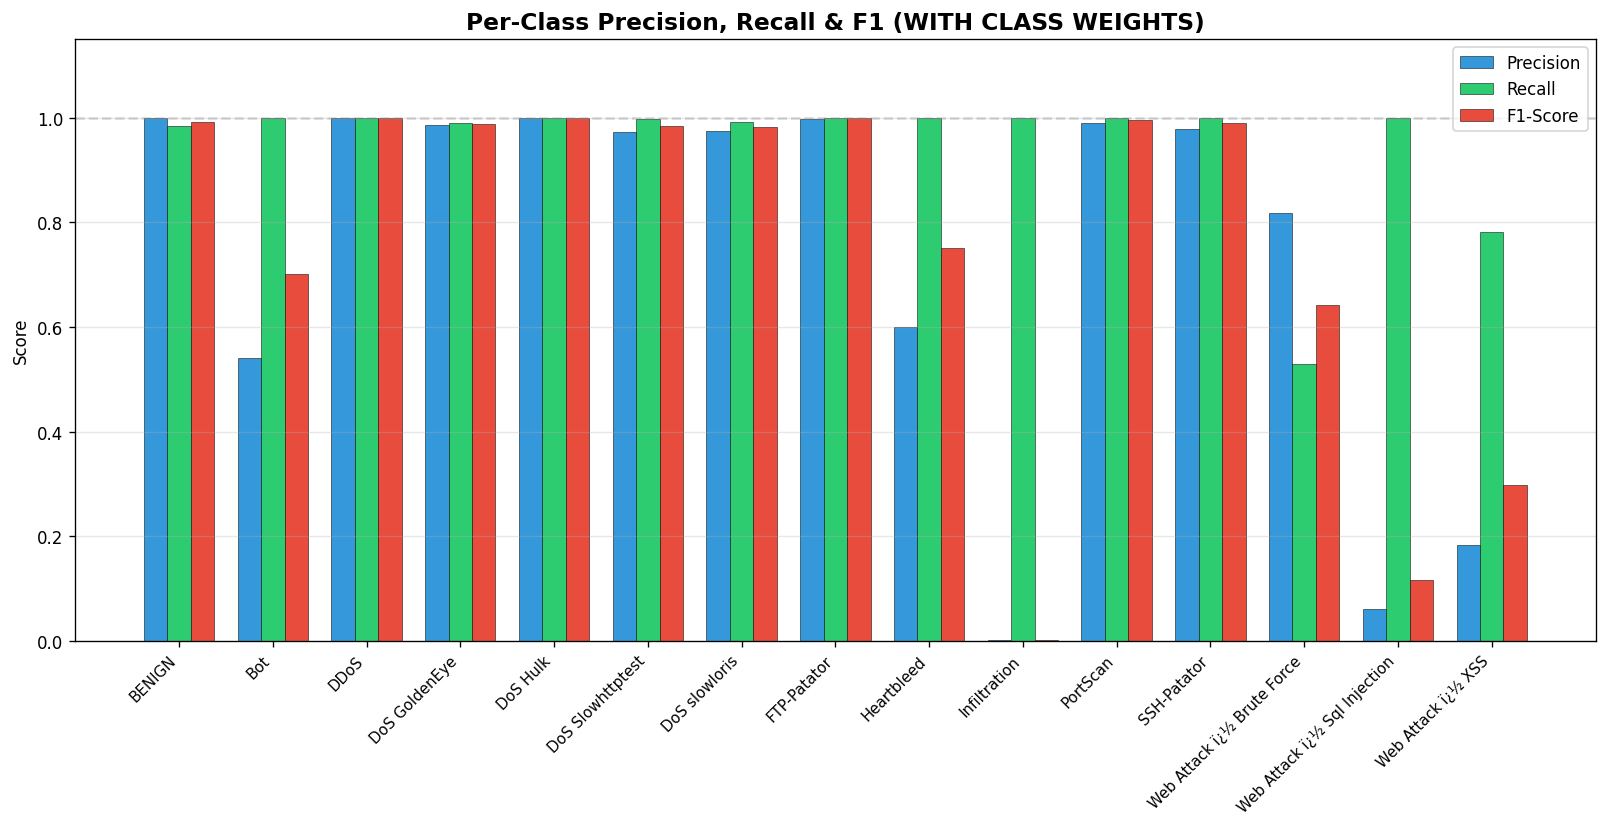

Saved: classification_report_balanced.png


In [14]:
# Per-class precision, recall, F1-score
prec_p = precision_score(y_test, y_pred, average=None, zero_division=0)
rec_p  = recall_score(y_test, y_pred, average=None, zero_division=0)
f1_p   = f1_score(y_test, y_pred, average=None, zero_division=0)

x = np.arange(n_classes); w = 0.25
fig, ax = plt.subplots(figsize=(max(12, n_classes * 0.9), 7))
ax.bar(x - w, prec_p, w, label='Precision', color='#3498db', edgecolor='black', lw=0.3)
ax.bar(x,     rec_p,  w, label='Recall',    color='#2ecc71', edgecolor='black', lw=0.3)
ax.bar(x + w, f1_p,   w, label='F1-Score',  color='#e74c3c', edgecolor='black', lw=0.3)
ax.set_xticks(x); ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Score')
ax.set_title('Per-Class Precision, Recall & F1 (WITH CLASS WEIGHTS)', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.15); ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=1.0, color='gray', ls='--', alpha=0.3)
plt.tight_layout()
plt.savefig('classification_report_balanced.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: classification_report_balanced.png')

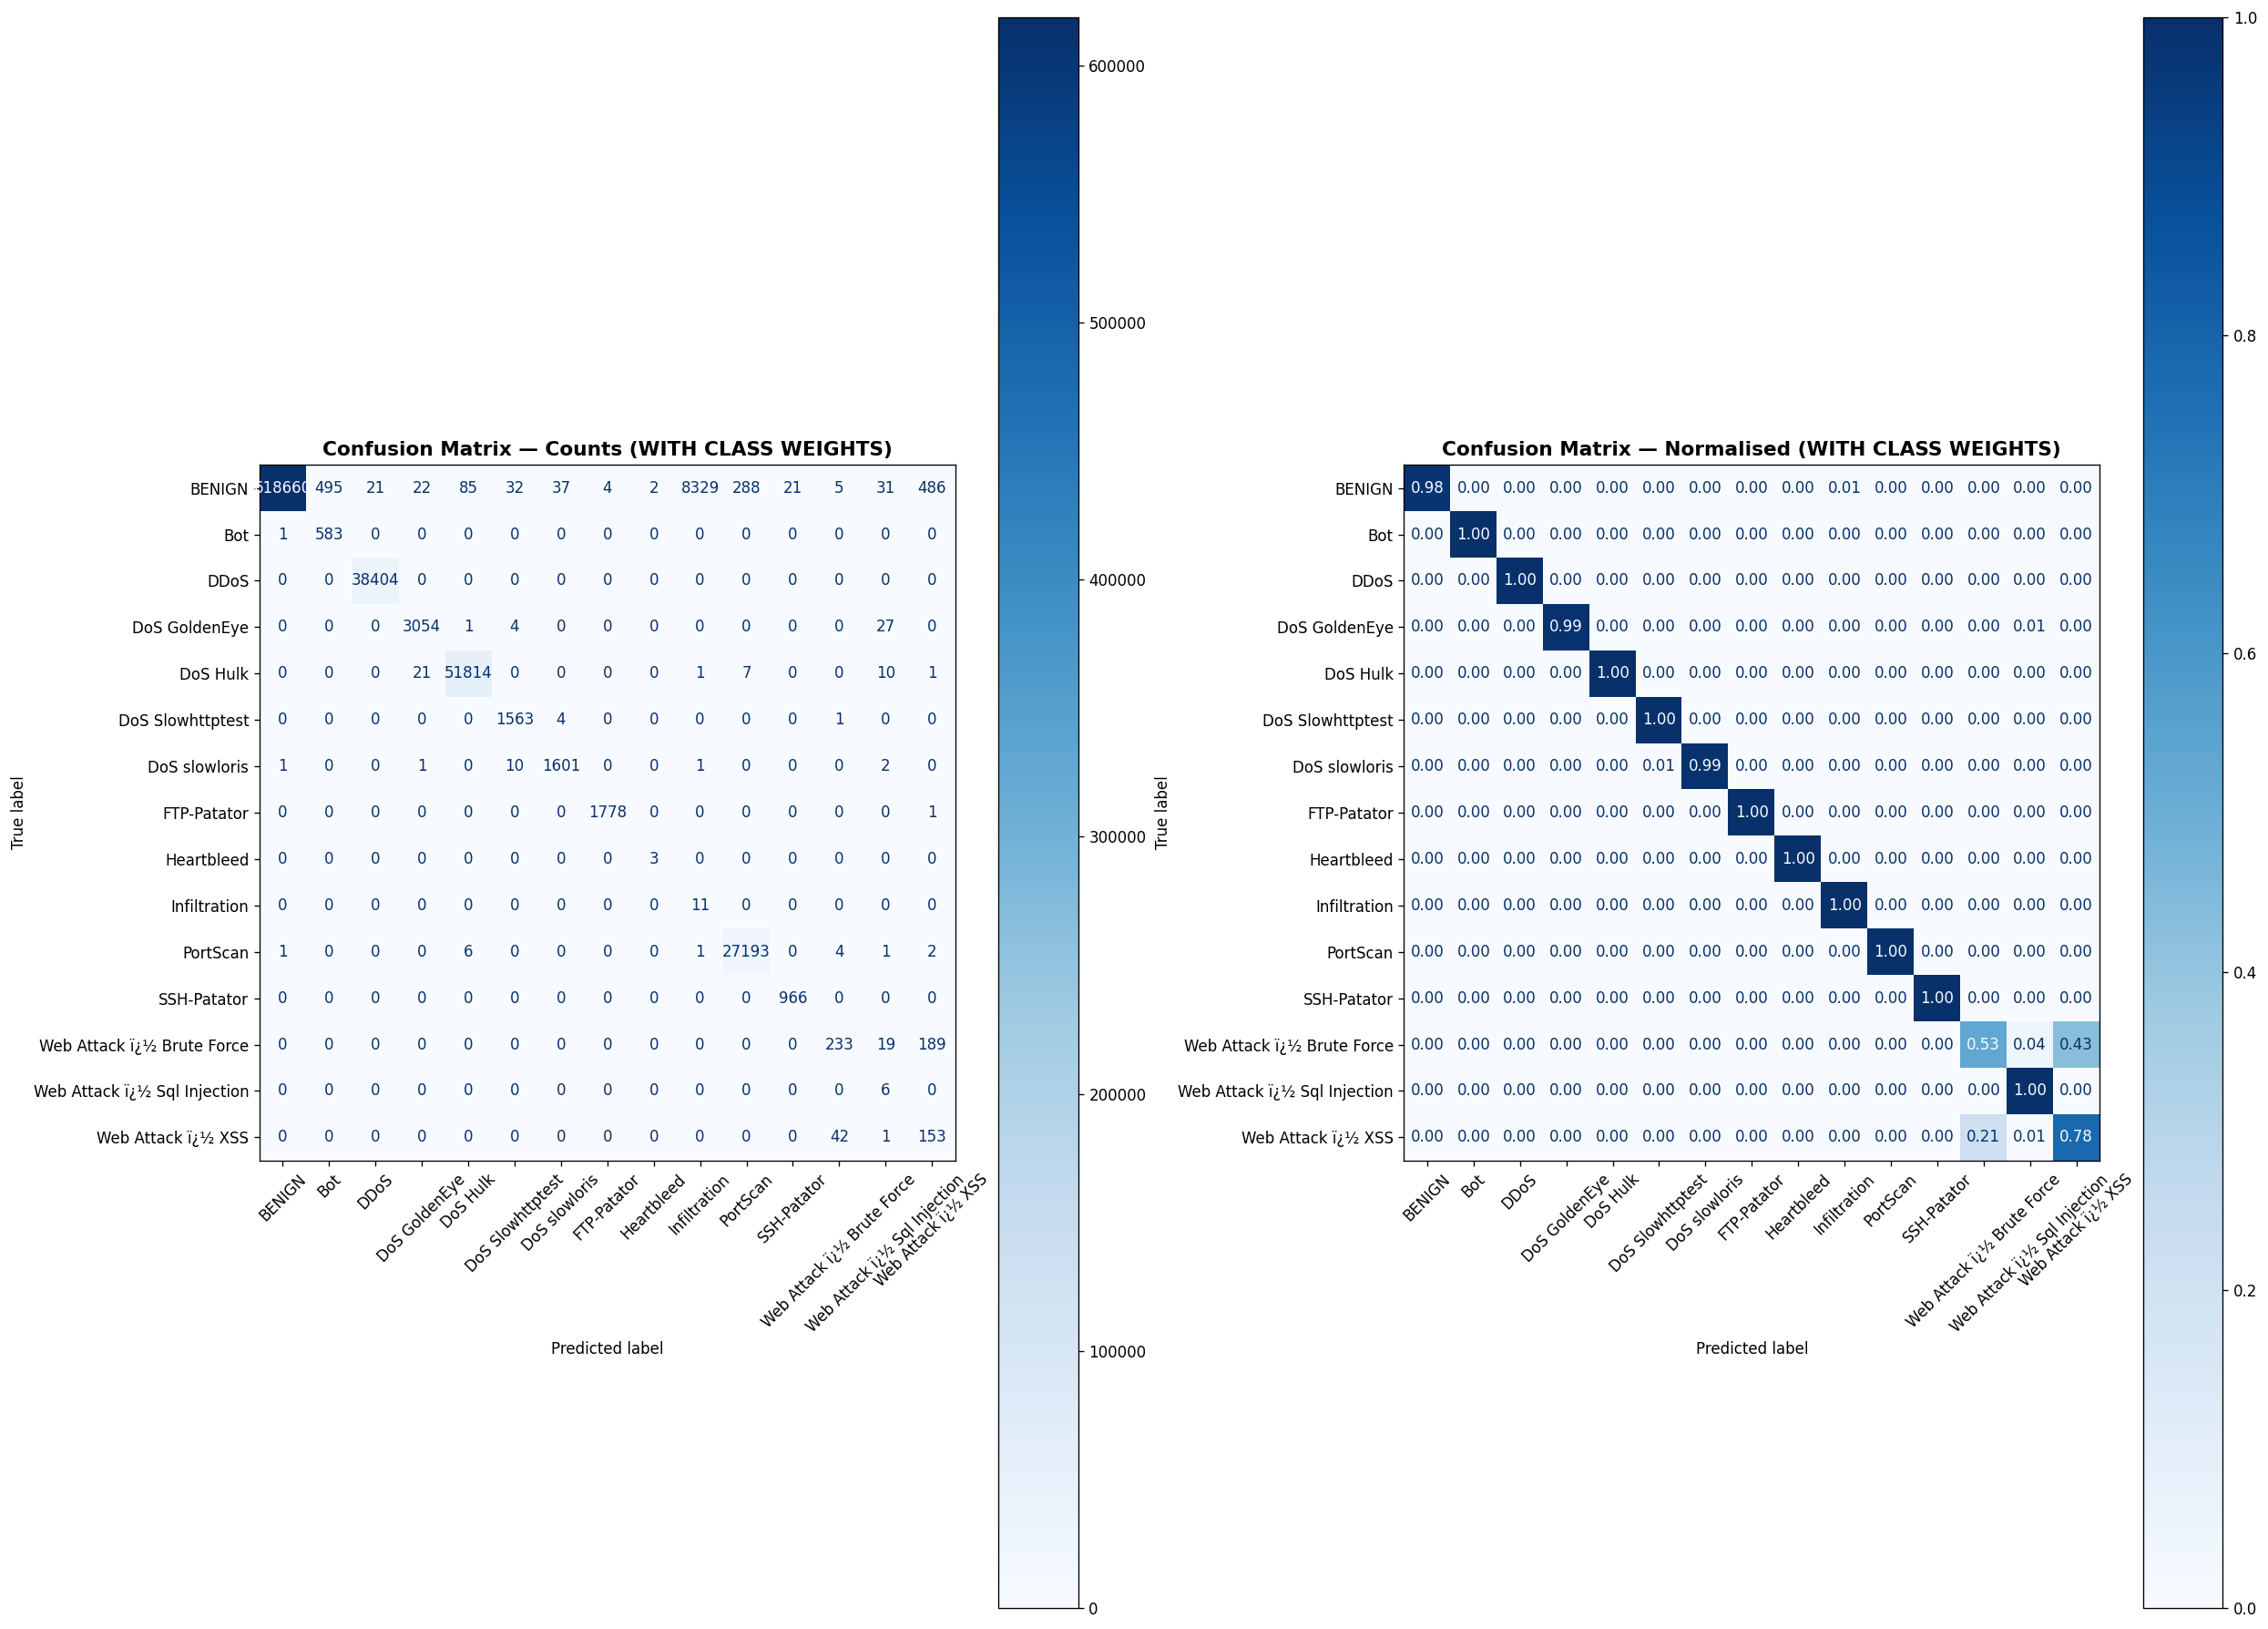

Saved: confusion_matrix_balanced.png


In [15]:
# Confusion Matrix (counts and normalized)
cm      = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(max(20, n_classes * 1.4), max(8, n_classes)))

ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
    ax=axes[0], cmap='Blues', colorbar=True, xticks_rotation=45, values_format='d')
axes[0].set_title('Confusion Matrix — Counts (WITH CLASS WEIGHTS)', fontsize=13, fontweight='bold')

ConfusionMatrixDisplay(cm_norm, display_labels=class_names).plot(
    ax=axes[1], cmap='Blues', colorbar=True, xticks_rotation=45, values_format='.2f')
axes[1].set_title('Confusion Matrix — Normalised (WITH CLASS WEIGHTS)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrix_balanced.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrix_balanced.png')

In [16]:
print("\n" + "="*80)
print("✅ RETRAINING COMPLETE!")
print("="*80)
print("\nChanges made:")
print("  • LightGBM: Added class_weight='balanced'")
print("  • Bagging: DecisionTree already had class_weight='balanced'")
print("  • Meta-learner: Added class_weight='balanced' to LogisticRegression")
print("\nExpected improvements:")
print("  • Better detection of minority classes (DDoS, PortScan, Infiltration)")
print("  • Reduced false negatives on rare attacks")
print("  • Better F1-scores for minority classes")
print("\nModels saved to ./saved_model/")
print("Flask backend will use the updated models automatically.")
print("="*80)


✅ RETRAINING COMPLETE!

Changes made:
  • LightGBM: Added class_weight='balanced'
  • Bagging: DecisionTree already had class_weight='balanced'
  • Meta-learner: Added class_weight='balanced' to LogisticRegression

Expected improvements:
  • Better detection of minority classes (DDoS, PortScan, Infiltration)
  • Reduced false negatives on rare attacks
  • Better F1-scores for minority classes

Models saved to ./saved_model/
Flask backend will use the updated models automatically.
